In [37]:
!pip install gymnasium
!pip install highway-env
!pip install torch

Import all relevant libraries

In [38]:
import sys
import gymnasium as gym
import highway_env
import numpy as np
import matplotlib.pyplot as plt

if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
#from gym.wrappers.monitoring import video_recorder

/var/folders/7y/tb8vlfv937523rgqdlf0zjy40000gn/T/ipykernel_68188/2395169701.py:7: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not hasattr(np, 'bool8'):


Write up a DQN class that builds the model, build the replay buffer, implements epsilon-greedy exploration and updates the Q network.

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class DQNNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQNNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 32)  # Reduced from 64
        self.fc2 = nn.Linear(32, 32)  # Reduced from 64
        self.fc3 = nn.Linear(32, 16)  # Reduced from 32
        self.fc4 = nn.Linear(16, action_size)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

class DQNAgent:
    def __init__(self, state_size, action_list):
        self.state_size = state_size
        self.action_list = action_list
        self.memory = []
        self.max_memory_size = 5000  # Reduced for faster CPU training
        self.gamma = 0.99  # Increased discount rate for long-term planning
        self.epsilon = 1.0  # exploration rate
        self.epsilon_min = 0.05  # Slightly higher minimum for continued exploration
        self.epsilon_decay = 0.99  # Faster decay for quick testing
        self.learning_rate = 0.001
        self.total_reward = []
        # Device configuration
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Vanilla DQN: single Q-network (no target network)
        self.model = DQNNetwork(self.state_size, len(self.action_list)).to(self.device)
        
        # Optimizer
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.criterion = nn.MSELoss()

    def remember(self, state, action, reward, next_state, done):
        # This function pushes instances of experience into the replay buffer
        self.memory.append((state, action, reward, next_state, done))
        if len(self.memory) > self.max_memory_size:
            self.memory.pop(0)

    def act(self, state, action_list):
        # epsilon-greedy exploration to select actions
        if np.random.rand() <= self.epsilon:
            action_idx = np.random.randint(len(action_list))
        else:
            state_tensor = torch.FloatTensor(state).to(self.device)
            self.model.eval()
            with torch.no_grad():
                act_values = self.model(state_tensor)
            self.model.train()
            action_idx = torch.argmax(act_values[0]).item()
        return action_list[action_idx]  # Map index to actual action

    def replay(self, batch_size):
        minibatch = np.random.choice(len(self.memory), batch_size, replace=False)
        states = np.array([self.memory[i][0].flatten() for i in minibatch])
        actions = np.array([self.memory[i][1] for i in minibatch])
        rewards = np.array([self.memory[i][2] for i in minibatch])
        next_states = np.array([self.memory[i][3].flatten() for i in minibatch])
        dones = np.array([self.memory[i][4] for i in minibatch])

        # Convert to tensors
        states_tensor = torch.FloatTensor(states).to(self.device)
        actions_tensor = torch.LongTensor(actions).to(self.device)
        rewards_tensor = torch.FloatTensor(rewards).to(self.device)
        next_states_tensor = torch.FloatTensor(next_states).to(self.device)
        dones_tensor = torch.FloatTensor(dones).to(self.device)

        # Vanilla DQN bootstrapping uses the same (online) network for next-state Q-values
        self.model.eval()
        with torch.no_grad():
            next_q_values = self.model(next_states_tensor)
            max_next_q_values = torch.max(next_q_values, dim=1)[0]
        self.model.train()
        targets = rewards_tensor + self.gamma * max_next_q_values * (1 - dones_tensor)
        
        # Get current Q values
        current_q_values = self.model(states_tensor)
        current_q_values_for_actions = current_q_values.gather(1, actions_tensor.unsqueeze(1)).squeeze(1)
        
        # Compute loss
        loss = self.criterion(current_q_values_for_actions, targets)
        
        # Backward pass
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def train(self, env, episodes=200):
        BATCH_SIZE = 32  # Reduced for faster CPU training
        MIN_MEMORY_SIZE = 200  # Reduced for faster training start
        total_reward = []

        for e in range(episodes):
            state, _ = env.reset()
            state = np.reshape(state, [1, self.state_size])
            done = False
            reward_count = 0
            steps = 0

            while not done:
                action = self.act(state, self.action_list)
                action_idx = self.action_list.index(action)
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                reward_count += reward
                next_state = np.reshape(next_state, [1, self.state_size])
                self.remember(state, action_idx, reward, next_state, done)
                state = next_state
                steps += 1

                # Only train after collecting enough experiences
                if len(self.memory) > MIN_MEMORY_SIZE:
                    self.replay(BATCH_SIZE)

            total_reward.append(reward_count)
            print(f"Episode {e+1}/{episodes}, Reward: {reward_count:.2f}, Steps: {steps}, Epsilon: {self.epsilon:.3f}")

        env.close()
        return total_reward

    def load(self, name):
        try:
            state_dict = torch.load(name, map_location=self.device, weights_only=True)
        except TypeError:
            state_dict = torch.load(name, map_location=self.device)
        self.model.load_state_dict(state_dict)

    def save(self, name):
        torch.save(self.model.state_dict(), name)

### Transition Model

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import torch.nn.functional as F
import numpy as np

class TransitionModelLearnerDQN(nn.Module):
    """MLP model to predict next state for diagonal actions (4-7)"""
    def __init__(self, state_dim=2, action_dim=1, hidden_dim=64, lr=0.001, buffer_size=10000):
        super(TransitionModelLearnerDQN, self).__init__()
        
        # Neural network layers
        input_dim = state_dim + action_dim  # state + action
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, state_dim)  # output_dim = state_dim
        self.dropout = nn.Dropout(0.1)
        
        # Training components
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(self.device)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.criterion = nn.MSELoss()
        
        self.buffer = deque(maxlen=buffer_size) #auto remove old samples if over size
        self.min_buffer_size = 100  # Minimum samples before training
        
    def forward(self, x):
        """Forward pass through the neural network"""
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x
        
    def add_experience(self, state, next_state, action, actions_list):
        min_action = min(actions_list)
        max_action = max(actions_list)
        action_features = np.array([(action - min_action) / (max_action - min_action)])  # Normalize to [0,1]
        self.buffer.append((state, action_features, next_state))
    
    def can_predict(self):
        return len(self.buffer) >= self.min_buffer_size
    
    def train_model(self, batch_size=32, epochs=10):
        if len(self.buffer) < self.min_buffer_size:
            return
        states = []
        actions = []
        next_states = []
        sample_size = min(len(self.buffer), 1000)  #  last 1000 samples
        samples = list(self.buffer)[-sample_size:]
        
        for state_feat, action_feat, next_state_feat in samples:
            states.append(state_feat.flatten())
            actions.append(action_feat)
            next_states.append(next_state_feat.flatten())
        
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.FloatTensor(np.array(actions)).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        self.train()
        for _ in range(epochs):
            indices = torch.randperm(len(states))
            for i in range(0, len(states), batch_size):
                batch_indices = indices[i:i+batch_size]
                batch_states = states[batch_indices]
                batch_actions = actions[batch_indices]
                batch_next_states = next_states[batch_indices]
                
                # Ensure batch_actions has shape [batch_size, 1] for concatenation
                if batch_actions.dim() == 1:
                    batch_actions = batch_actions.unsqueeze(1)
                
                # Concatenate state and action
                batch_input = torch.cat([batch_states, batch_actions], dim=1)
                # forward 
                predicted_next_states = self(batch_input)
                loss = self.criterion(predicted_next_states, batch_next_states)
                
                # backward 
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
    
    def predict_next_state(self, state, state_size, action, actions_list):
        self.eval()
        with torch.no_grad():
            min_action = min(actions_list)
            max_action = max(actions_list)
            action_features = np.array([(action - min_action) / (max_action - min_action)])  # Normalize to [0,1]
            state = state.flatten()
            input_features = np.concatenate([state, action_features])
            input_features = np.reshape(input_features, [1, state_size + 1])
            input_tensor = torch.FloatTensor(input_features).to(self.device)
            
            predicted = self(input_tensor)
            predicted_np = predicted.cpu().numpy()
            return predicted_np

### DQN_MLP

##### Transition model 

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import torch.nn.functional as F
import numpy as np

class TransitionModelLearnerDQN(nn.Module):
    """MLP model to predict next state for diagonal actions (4-7)"""
    def __init__(self, state_dim=2, action_dim=1, hidden_dim=64, lr=0.001, buffer_size=10000):
        super(TransitionModelLearnerDQN, self).__init__()
        
        # Neural network layers
        input_dim = state_dim + action_dim  # state + action
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, state_dim)  # output_dim = state_dim
        self.dropout = nn.Dropout(0.1)
        
        # Training components
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(self.device)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.criterion = nn.MSELoss()
        
        self.buffer = deque(maxlen=buffer_size) #auto remove old samples if over size
        self.min_buffer_size = 100  # Minimum samples before training
        
    def forward(self, x):
        """Forward pass through the neural network"""
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x
        
    def add_experience(self, state, next_state, action, actions_list):
        min_action = min(actions_list)
        max_action = max(actions_list)
        action_features = np.array([(action - min_action) / (max_action - min_action)])  # Normalize to [0,1]
        self.buffer.append((state, action_features, next_state))
    
    def can_predict(self):
        return len(self.buffer) >= self.min_buffer_size
    
    def train_model(self, batch_size=32, epochs=10):
        if len(self.buffer) < self.min_buffer_size:
            return
        states = []
        actions = []
        next_states = []
        sample_size = min(len(self.buffer), 1000)  #  last 1000 samples
        samples = list(self.buffer)[-sample_size:]
        
        for state_feat, action_feat, next_state_feat in samples:
            states.append(state_feat.flatten())
            actions.append(action_feat)
            next_states.append(next_state_feat.flatten())
        
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.FloatTensor(np.array(actions)).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        self.train()
        for _ in range(epochs):
            indices = torch.randperm(len(states))
            for i in range(0, len(states), batch_size):
                batch_indices = indices[i:i+batch_size]
                batch_states = states[batch_indices]
                batch_actions = actions[batch_indices]
                batch_next_states = next_states[batch_indices]
                
                # Ensure batch_actions has shape [batch_size, 1] for concatenation
                if batch_actions.dim() == 1:
                    batch_actions = batch_actions.unsqueeze(1)
                
                # Concatenate state and action
                batch_input = torch.cat([batch_states, batch_actions], dim=1)
                # forward 
                predicted_next_states = self(batch_input)
                loss = self.criterion(predicted_next_states, batch_next_states)
                
                # backward 
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
    
    def predict_next_state(self, state, state_size, action, actions_list):
        self.eval()
        with torch.no_grad():
            min_action = min(actions_list)
            max_action = max(actions_list)
            action_features = np.array([(action - min_action) / (max_action - min_action)])  # Normalize to [0,1]
            state = state.flatten()
            input_features = np.concatenate([state, action_features])
            input_features = np.reshape(input_features, [1, state_size + 1])
            input_tensor = torch.FloatTensor(input_features).to(self.device)
            
            predicted = self(input_tensor)
            predicted_np = predicted.cpu().numpy()
            return predicted_np

### DQN_MLP_Agent

In [42]:
import sys
import numpy as np
import gymnasium as gym
import highway_env
import matplotlib.pyplot as plt
from importlib import reload

if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

#from gym.wrappers.monitoring import video_recorder

class MLPNetwork(nn.Module):
    """MLP Network for DQN_MLP_Agent"""
    def __init__(self, state_size, action_size):
        super(MLPNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 16)  # Reduced from 24
        self.fc2 = nn.Linear(16, 16)  # Reduced from 24
        self.fc3 = nn.Linear(16, action_size)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class DQN_MLP_Agent:
    def __init__(self, state_size, action_size, fine_tune_model=None):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = []
        self.gamma = 0.9  # discount rate
        self.epsilon = 1.0  # exploration rate
        self.epsilon_min = 0.01 # minimum epsilon
        self.epsilon_decay = 0.99  # Faster decay for quick testing
        self.learning_rate = 0.001
        self.total_reward = []
        # Device configuration
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Build model
        if fine_tune_model is not None:
            self.model = fine_tune_model.to(self.device)
        else:
            self.model = self._build_model()
        
        # Optimizer and loss
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.criterion = nn.MSELoss()
        
        self.transition_learner = TransitionModelLearnerDQN(state_dim=state_size, action_dim=1)
        self.rng = np.random.default_rng(123)
        
    def _build_model(self):
        #this function builds the MLP model with relu activations in 2 the hidden layers, and linear activation in the output layer
        model = MLPNetwork(self.state_size, self.action_size).to(self.device)
        return model

    def remember(self, state, action, reward, next_state, done):
        #This function pushes instances of experience into the replay buffer
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state, action_list):
        #epsilon-greedy exploration to select actions
        if np.random.rand() <= self.epsilon:
            return np.random.choice(action_list)
        
        state_tensor = torch.FloatTensor(state).to(self.device)
        self.model.eval()
        with torch.no_grad():
            act_values = self.model(state_tensor)
        self.model.train()
        return torch.argmax(act_values[0]).item()
    
    def enhanced_epsilon_greedy(self, state, base_action_list, extend_action_list, epsilon, rng, encourage_new_action=False):
        if encourage_new_action:
            if rng.random() < 0.3:  
                return np.random.choice(extend_action_list)
        # Standard epsilon-greedy
        if rng.random() < epsilon:
                return np.random.choice(extend_action_list + base_action_list)

        state_tensor = torch.FloatTensor(state).to(self.device)
        self.model.eval()
        with torch.no_grad():
            act_values = self.model(state_tensor)
        self.model.train()
        return torch.argmax(act_values[0]).item()

    
    def replay(self, batch_size):
        minibatch = np.random.choice(len(self.memory), batch_size, replace=False)#select a minibatch of size batch_size
        states = np.array([self.memory[i][0].flatten() for i in minibatch])
        actions = np.array([self.memory[i][1] for i in minibatch])
        rewards = np.array([self.memory[i][2] for i in minibatch])
        next_states = np.array([self.memory[i][3].flatten() for i in minibatch])
        dones = np.array([self.memory[i][4] for i in minibatch])

        # Convert to tensors
        states_tensor = torch.FloatTensor(states).to(self.device)
        actions_tensor = torch.LongTensor(actions).to(self.device)
        rewards_tensor = torch.FloatTensor(rewards).to(self.device)
        next_states_tensor = torch.FloatTensor(next_states).to(self.device)
        dones_tensor = torch.FloatTensor(dones).to(self.device)

        # Get next state Q-values
        self.model.eval()
        with torch.no_grad():
            next_q_values = self.model(next_states_tensor)
            max_next_q_values = torch.max(next_q_values, dim=1)[0]
        
        # Calculate targets
        targets = rewards_tensor + self.gamma * max_next_q_values * (1 - dones_tensor)
        
        # Get current Q values
        self.model.train()
        current_q_values = self.model(states_tensor)
        current_q_values_for_actions = current_q_values.gather(1, actions_tensor.unsqueeze(1)).squeeze(1)
        
        # Compute loss
        loss = self.criterion(current_q_values_for_actions, targets)
        
        # Backward pass
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def load(self, name):
        self.model.load_state_dict(torch.load(name, map_location=self.device))

    def save(self, name):
        torch.save(self.model.state_dict(), name)
        
    def train(self, env, base_actions, expand_actions, episodes=200):
        model_train_frequency = 5
        batch_size = 32 #set batch size
        total_rewards_log = []
        eps = self.epsilon
        self.reuse = 0
        self.reject = 0
        for ep in range(episodes):
            state, info = env.reset()
            state = np.reshape(state, [1, self.state_size])
            total_reward=0
            done = False
            while done is False:#upto 200 steps in the episode
                
                action = self.enhanced_epsilon_greedy(state, base_actions, expand_actions, eps, self.rng, encourage_new_action= ep < 30) # This part encourages exploration of new actions 
                
                if action in expand_actions and self.transition_learner.can_predict(): 
                    snext_model = self.transition_learner.predict_next_state(state, self.state_size, action, expand_actions)
                    
                    # Use PyTorch model for prediction
                    snext_model_tensor = torch.FloatTensor(snext_model).to(self.device)
                    state_tensor = torch.FloatTensor(state).to(self.device)
                    
                    self.model.eval()
                    with torch.no_grad():
                        q_values_next_state_model = self.model(snext_model_tensor)
                        q_value_current_state = self.model(state_tensor)
                    self.model.train()
                    
                    if torch.max(q_values_next_state_model).item() > torch.max(q_value_current_state).item():  
                        self.reuse += 1
                    else: 
                        self.reject += 1
                        action = self.act(state, base_actions + expand_actions)
                        
                next_state, reward, done, truncated, _ = env.step(action)#take the action, get reward and next state
                
                if action in expand_actions:
                    self.transition_learner.add_experience(state, next_state, action, expand_actions)        
                
                done = done or truncated
                total_reward+=reward# keep track of total rewards
                next_state = np.reshape(next_state, [1, self.state_size])#reshape states to vectorised form
                self.remember(state, action, reward, next_state, done)#store in replay buffer
                state = next_state
                
                if ep > 0 and ep % model_train_frequency == 0 and len(self.transition_learner.buffer) > 50:
                    self.transition_learner.train_model(batch_size=32, epochs=2)
                
                if len(self.memory) > batch_size:#if there are enough samples to form a batch then call experience replay
                    self.replay(batch_size)#update the DQN weights through replay
            total_rewards_log.append(total_reward)#log the total rewards in the episode
            
            if (ep + 1) % 10 == 0:
                print(f"Episode {ep+1}/{episodes}, Total Reward: {total_reward:.2f}, Epsilon: {self.epsilon:.3f}, Reuse: {self.reuse}, Reject: {self.reject}")
        
        env.close()
        return total_rewards_log

/var/folders/7y/tb8vlfv937523rgqdlf0zjy40000gn/T/ipykernel_68188/1488983013.py:8: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not hasattr(np, 'bool8'):


Let's put it all together in the main loop.

### Run Multiple Experiments for Statistical Analysis

In [43]:
EPISODES_TRAIN = 100  # Reduced for quick CPU testing (was 600)

In [44]:
env = gym.make("highway-v0", render_mode="rgb_array")

# Use FULL action space for better learning
# {'LANE_LEFT': 0, 'IDLE': 1, 'LANE_RIGHT': 2, 'FASTER': 3, 'SLOWER': 4}
FULL_ACTION_LIST = [0, 1, 2, 3, 4]
# Handle observation space - flatten if needed
BASE_ACTIONS = [0, 2]  # Define base actions: left and right
EXPAND_ACTIONS = [1, 3, 4]

obs_space = env.observation_space
if hasattr(obs_space, 'shape'):
    state_size = np.prod(obs_space.shape)
else:
    state_size = obs_space.n

print(f"State size: {state_size}")
print(f"Action space: {BASE_ACTIONS}")

base_agent = DQNAgent(state_size, FULL_ACTION_LIST)  # Use full action list

base_total_reward_log = base_agent.train(env, episodes=EPISODES_TRAIN)  # Train for more episodes
# Save the trained model
base_agent.save("highway_dqn_model.pth")

State size: 25
Action space: [0, 2]
Episode 1/100, Reward: 7.22, Steps: 9, Epsilon: 1.000
Episode 2/100, Reward: 3.20, Steps: 5, Epsilon: 1.000
Episode 3/100, Reward: 10.22, Steps: 12, Epsilon: 1.000
Episode 4/100, Reward: 3.67, Steps: 5, Epsilon: 1.000
Episode 5/100, Reward: 5.75, Steps: 8, Epsilon: 1.000
Episode 6/100, Reward: 5.02, Steps: 7, Epsilon: 1.000
Episode 7/100, Reward: 12.04, Steps: 16, Epsilon: 1.000
Episode 8/100, Reward: 21.08, Steps: 28, Epsilon: 1.000
Episode 9/100, Reward: 14.26, Steps: 18, Epsilon: 1.000
Episode 10/100, Reward: 1.93, Steps: 3, Epsilon: 1.000
Episode 11/100, Reward: 1.89, Steps: 3, Epsilon: 1.000
Episode 12/100, Reward: 10.57, Steps: 13, Epsilon: 1.000
Episode 13/100, Reward: 1.89, Steps: 3, Epsilon: 1.000
Episode 14/100, Reward: 12.88, Steps: 17, Epsilon: 1.000
Episode 15/100, Reward: 6.61, Steps: 9, Epsilon: 1.000
Episode 16/100, Reward: 13.73, Steps: 17, Epsilon: 1.000
Episode 17/100, Reward: 20.55, Steps: 27, Epsilon: 1.000
Episode 18/100, Reward

In [45]:
def run_multiple_experiments(n_runs=5, base_seed=123, episodes=200, model_path = "highway_dqn_model.pth"):
    """Run multiple training experiments with different seeds and return statistics"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Storage for all runs
    all_returns_base = []
    all_returns_full = []
    all_reuse_counts = []
    all_reject_counts = []
    
    for run in range(n_runs):
        current_seed = base_seed + run * 42
        # Reset random seeds
        np.random.seed(current_seed)
        torch.manual_seed(current_seed)
        
        print(f"\n{'='*60}")
        print(f"Running experiment {run + 1}/{n_runs} (seed={current_seed})")
        print(f"{'='*60}")
        
        # Create fresh environment
        env_run = gym.make("highway-v0", render_mode="rgb_array")
        
        # 1. Train base agent with BASE_ACTIONS
        print(f"\n[Run {run+1}] Training base agent (2 actions)...")
        base_agent_run = DQNAgent(state_size, FULL_ACTION_LIST)
        base_returns = base_agent_run.train(env_run, episodes=episodes)
        all_returns_base.append(base_returns)
        
        # 2. Load base model and expand to full action space
        env_run = gym.make("highway-v0", render_mode="rgb_array")  # Recreate env
        base_state_dict_run = torch.load(model_path, map_location=device, weights_only=True)
        
        # Build and expand model for full action space
        fine_tune_model_run = DQNNetwork(state_size, len(FULL_ACTION_LIST)).to(device)
        filtered_state_dict_run = {k: v for k, v in base_state_dict_run.items() 
                                   if not k.startswith("fc4.")}
        fine_tune_model_run.load_state_dict(filtered_state_dict_run, strict=False)
        
        # Expand fc4 (last layer) from 2 actions -> 5 actions
        base_w_run = base_state_dict_run["fc4.weight"].to(device)
        base_b_run = base_state_dict_run["fc4.bias"].to(device)
        
        new_w_run = fine_tune_model_run.fc4.weight.detach().clone()
        new_b_run = fine_tune_model_run.fc4.bias.detach().clone()
        
        n_actions_base_run = base_w_run.shape[0]
        n_actions_full_run = len(FULL_ACTION_LIST)
        
        # Keep learned 2 actions
        new_w_run[:n_actions_base_run] = base_w_run
        new_b_run[:n_actions_base_run] = base_b_run
        
        # Initialize extra actions with variations of learned actions
        for i in range(n_actions_base_run, n_actions_full_run):
            src = np.random.randint(0, n_actions_base_run)
            new_w_run[i] = base_w_run[src]
            new_b_run[i] = base_b_run[src]
        
        with torch.no_grad():
            fine_tune_model_run.fc4.weight.copy_(new_w_run)
            fine_tune_model_run.fc4.bias.copy_(new_b_run)
        
        # 3. Train full agent with expanded action space
        print(f"\n[Run {run+1}] Training full agent (5 actions)...")
        full_agent_run = DQN_MLP_Agent(state_size, n_actions_full_run, 
                                       fine_tune_model=fine_tune_model_run)
        full_returns = full_agent_run.train(env_run, BASE_ACTIONS, EXPAND_ACTIONS, episodes=episodes)
        all_returns_full.append(full_returns)
        
        # Collect reuse statistics
        all_reuse_counts.append(full_agent_run.reuse if hasattr(full_agent_run, 'reuse') else 0)
        all_reject_counts.append(full_agent_run.reject if hasattr(full_agent_run, 'reject') else 0)
        
        print(f"\n[Run {run+1}] Summary:")
        print(f"  Base agent final reward: {base_returns[-1]:.2f}")
        print(f"  Full agent final reward: {full_returns[-1]:.2f}")
        print(f"  Reuse count: {all_reuse_counts[-1]}")
        print(f"  Reject count: {all_reject_counts[-1]}")
    
    # Calculate statistics
    all_returns_base = np.array(all_returns_base)
    all_returns_full = np.array(all_returns_full)
    
    return {
        'returns': {
            'base': {'mean': np.mean(all_returns_base, axis=0), 
                    'std': np.std(all_returns_base, axis=0)},
            'full': {'mean': np.mean(all_returns_full, axis=0), 
                    'std': np.std(all_returns_full, axis=0)},
        },
        'info': {
            'reuse_counts': all_reuse_counts,
            'reject_counts': all_reject_counts
        }
    }


def plot_multiple_experiments(stats, window=10, figsize=(14, 6)):
    """Plot results from multiple experiments with shaded error bars"""
    
    # Apply moving average to smooth curves
    def moving_avg(data, w):
        return np.convolve(data, np.ones(w)/w, mode='valid')
    
    base_mean = stats['returns']['base']['mean']
    base_std = stats['returns']['base']['std']
    full_mean = stats['returns']['full']['mean']
    full_std = stats['returns']['full']['std']
    
    # Apply smoothing
    base_mean_smooth = moving_avg(base_mean, window)
    base_std_smooth = moving_avg(base_std, window)
    full_mean_smooth = moving_avg(full_mean, window)
    full_std_smooth = moving_avg(full_std, window)
    
    # Create x-axis
    x_base = np.arange(len(base_mean_smooth))
    x_full = np.arange(len(full_mean_smooth))
    
    # Plot returns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Returns plot
    ax1.plot(x_base, base_mean_smooth, color='blue', 
            label='Navie Train Agent (5 actions)', linewidth=2)
    ax1.fill_between(x_base, 
                     base_mean_smooth - base_std_smooth,
                     base_mean_smooth + base_std_smooth,
                     color='blue', alpha=0.2)
    
    ax1.plot(x_full, full_mean_smooth, color='green', 
            label='Our menthod (5 actions, MLP-based)', linewidth=2)
    ax1.fill_between(x_full,
                     full_mean_smooth - full_std_smooth,
                     full_mean_smooth + full_std_smooth,
                     color='green', alpha=0.2)
    
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Total Reward')
    ax1.set_title('Training Rewards: Base vs Full Agent')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Reuse/Reject statistics
    reuse_counts = stats['info']['reuse_counts']
    reject_counts = stats['info']['reject_counts']
    
    x_runs = np.arange(1, len(reuse_counts) + 1)
    width = 0.35
    
    ax2.bar(x_runs - width/2, reuse_counts, width, 
           color='green', label='Reuse', alpha=0.8)
    ax2.bar(x_runs + width/2, reject_counts, width, 
           color='red', label='Reject', alpha=0.8)
    
    ax2.set_xlabel('Run')
    ax2.set_ylabel('Count')
    ax2.set_title('Model Reuse vs Reject per Run')
    ax2.legend()
    ax2.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    print(f"\nNavie Train Agent (5 actions):")
    print(f"  Final reward (mean ± std): {base_mean[-1]:.2f} ± {base_std[-1]:.2f}")
    print(f"  Max reward achieved: {np.max(base_mean):.2f}")
    
    print(f"\nOur Agent (5 actions):")
    print(f"  Final reward (mean ± std): {full_mean[-1]:.2f} ± {full_std[-1]:.2f}")
    print(f"  Max reward achieved: {np.max(full_mean):.2f}")
    
    print(f"\nModel Reuse Statistics:")
    print(f"  Average reuse per run: {np.mean(reuse_counts):.2f} ± {np.std(reuse_counts):.2f}")
    print(f"  Average reject per run: {np.mean(reject_counts):.2f} ± {np.std(reject_counts):.2f}")
    print(f"  Reuse ratio: {np.mean(reuse_counts) / (np.mean(reuse_counts) + np.mean(reject_counts)) * 100:.1f}%")

### Execute Multiple Experiments (Warning: This will take a while!)

In [46]:
# Run multiple experiments for statistical analysis
# Note: Each run trains 2 agents (base + full), so this will take time
# Reduce n_runs or episodes if you need faster results

print("Starting multiple experiments...")
print("This will train multiple agents with different random seeds")
print("to provide statistical confidence in the results.\n")

# Run with 2 experiments for quick CPU testing
# Adjust n_runs and episodes based on your time/compute budget
stats = run_multiple_experiments(n_runs=2, base_seed=123, episodes=EPISODES_TRAIN)  # Quick test: 2 runs x 100 episodes


Starting multiple experiments...
This will train multiple agents with different random seeds
to provide statistical confidence in the results.


Running experiment 1/2 (seed=123)

[Run 1] Training base agent (2 actions)...
Episode 1/100, Reward: 2.86, Steps: 4, Epsilon: 1.000
Episode 2/100, Reward: 6.44, Steps: 9, Epsilon: 1.000
Episode 3/100, Reward: 11.69, Steps: 15, Epsilon: 1.000
Episode 4/100, Reward: 21.87, Steps: 25, Epsilon: 1.000
Episode 5/100, Reward: 13.61, Steps: 19, Epsilon: 1.000
Episode 6/100, Reward: 16.04, Steps: 20, Epsilon: 1.000
Episode 7/100, Reward: 22.39, Steps: 29, Epsilon: 1.000
Episode 8/100, Reward: 10.15, Steps: 14, Epsilon: 1.000
Episode 9/100, Reward: 4.59, Steps: 6, Epsilon: 1.000
Episode 10/100, Reward: 2.80, Steps: 4, Epsilon: 1.000
Episode 11/100, Reward: 5.93, Steps: 8, Epsilon: 1.000
Episode 12/100, Reward: 27.21, Steps: 32, Epsilon: 1.000
Episode 13/100, Reward: 1.73, Steps: 3, Epsilon: 1.000
Episode 14/100, Reward: 9.17, Steps: 11, Epsilon: 1.000
E

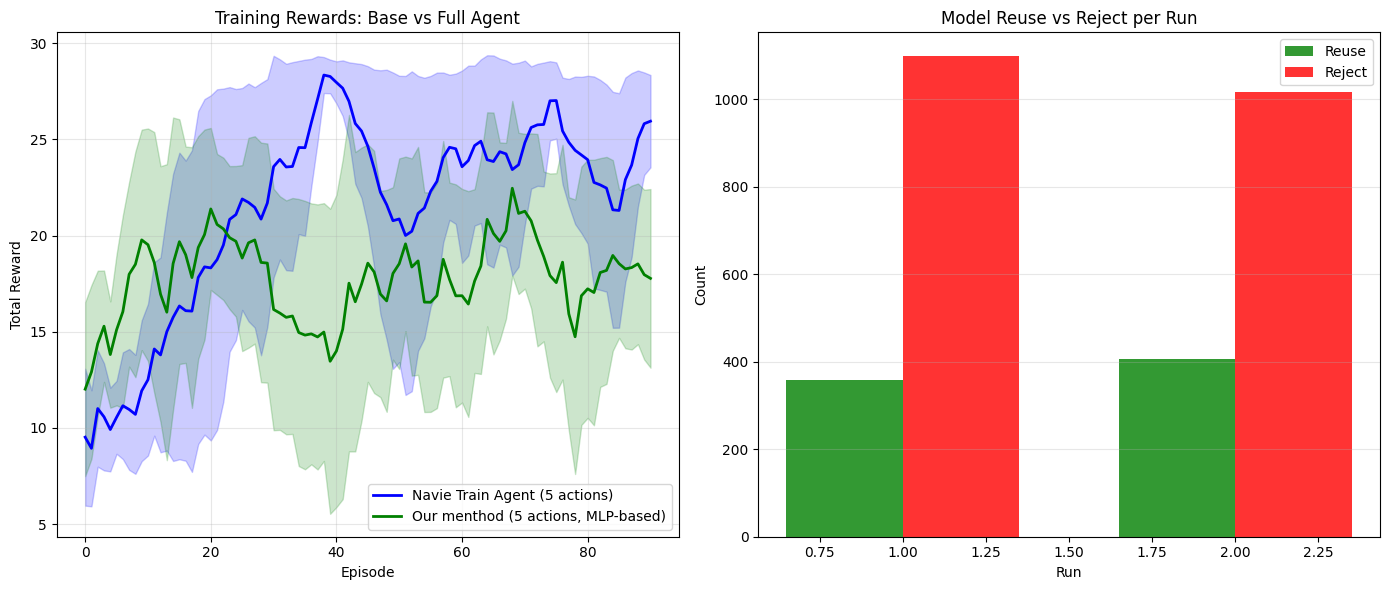


SUMMARY STATISTICS

Navie Train Agent (5 actions):
  Final reward (mean ± std): 27.76 ± 1.07
  Max reward achieved: 29.89

Our Agent (5 actions):
  Final reward (mean ± std): 17.71 ± 11.14
  Max reward achieved: 30.14

Model Reuse Statistics:
  Average reuse per run: 382.50 ± 24.50
  Average reject per run: 1057.50 ± 40.50
  Reuse ratio: 26.6%


In [47]:

# Plot the aggregated results
plot_multiple_experiments(stats, window=10)